# 🏭 FORECASTING DEEP DIVE - PRODUCTION READY FORECASTER

This notebook provides a production-ready forecasting system that:
1. Loads all trained models and data
2. Defines forecasting functions for all product segments
3. Generates complete preparation orders for any future date
4. Provides an API-ready function for integration

---

## STEP 1: LOAD ALL NECESSARY COMPONENTS

In [ ]:
# ===================================================================
# LOAD COMPLETE FORECASTING PIPELINE
# ===================================================================

import pandas as pd
import numpy as np
import pickle
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

print("Loading forecasting components...")

# Load complete data (up to yesterday)
df = pd.read_csv('../data/processed/features_complete.csv')
df['date'] = pd.to_datetime(df['date'])

# Load product segments
product_segments = pd.read_csv('../data/processed/product_segments.csv')

# Load Random Forest model
with open('../data/models/random_forest_model.pkl', 'rb') as f:
    rf_model = pickle.load(f)

with open('../data/models/feature_columns.pkl', 'rb') as f:
    feature_cols = pickle.load(f)

print(f"Data loaded: {len(df):,} rows")
print(f"Products: {df['id_produit'].nunique()}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Product segments: {product_segments['segment'].nunique()}")
print(f"Model features: {len(feature_cols)}")

## STEP 2: DEFINE FORECASTING FUNCTIONS

In [ ]:
# ===================================================================
# FORECASTING METHODS FOR ALL SEGMENTS
# ===================================================================

print("\nDefining forecasting functions...")

def naive_forecast(df, product_id, forecast_date, window=7):
    """Naive baseline: Average of last N days"""
    product_data = df[df['id_produit'] == product_id].copy()
    product_data = product_data.sort_values('date')
    
    recent_data = product_data[
        product_data['date'] < forecast_date
    ].tail(window)
    
    if len(recent_data) == 0:
        return 0
    
    return max(0, round(recent_data['quantite_demande'].mean()))


def weighted_moving_average(df, product_id, forecast_date, window=14):
    """Weighted MA with trend adjustment"""
    product_data = df[df['id_produit'] == product_id].copy()
    product_data = product_data.sort_values('date')
    
    recent_data = product_data[
        product_data['date'] < forecast_date
    ].tail(window)
    
    if len(recent_data) < 3:
        return naive_forecast(df, product_id, forecast_date)
    
    weights = np.exp(np.linspace(-1, 0, len(recent_data)))
    weights = weights / weights.sum()
    
    forecast = np.average(recent_data['quantite_demande'], weights=weights)
    
    # Trend adjustment
    if len(recent_data) >= 7:
        first_half = recent_data.iloc[:len(recent_data)//2]['quantite_demande'].mean()
        second_half = recent_data.iloc[len(recent_data)//2:]['quantite_demande'].mean()
        trend = second_half - first_half
        forecast = forecast + (trend * 0.3)
    
    return max(0, round(forecast))


def predict_random_forest(model, df, product_id, forecast_date, feature_cols):
    """Random Forest prediction"""
    product_data = df[df['id_produit'] == product_id].copy()
    product_data = product_data.sort_values('date')
    
    latest = product_data[product_data['date'] < forecast_date].tail(1)
    
    if len(latest) == 0:
        return weighted_moving_average(df, product_id, forecast_date)
    
    latest_copy = latest.copy()
    latest_copy['day_of_week'] = forecast_date.weekday()
    latest_copy['month'] = forecast_date.month
    latest_copy['week_of_year'] = forecast_date.isocalendar()[1]
    latest_copy['is_weekend'] = 1 if forecast_date.weekday() >= 5 else 0
    latest_copy['is_month_start'] = 1 if forecast_date.day <= 7 else 0
    latest_copy['is_month_end'] = 1 if forecast_date.day >= 24 else 0
    
    # Update cyclical features
    if 'month_sin' in feature_cols:
        latest_copy['month_sin'] = np.sin(2 * np.pi * forecast_date.month / 12)
        latest_copy['month_cos'] = np.cos(2 * np.pi * forecast_date.month / 12)
    if 'dow_sin' in feature_cols:
        latest_copy['dow_sin'] = np.sin(2 * np.pi * forecast_date.weekday() / 7)
        latest_copy['dow_cos'] = np.cos(2 * np.pi * forecast_date.weekday() / 7)
    
    try:
        X_pred = latest_copy[feature_cols]
        prediction = model.predict(X_pred)[0]
        return max(0, round(prediction))
    except Exception as e:
        print(f"  RF failed for {product_id}: {e}")
        return weighted_moving_average(df, product_id, forecast_date)

print("✓ Forecasting functions ready")

In [ ]:
# ===================================================================
# VISUALIZATION: Feature Importance from Saved Model
# ===================================================================

print("\nVisualizing feature importance from saved model...")

# Get feature importance from the loaded Random Forest model
feature_names = [
    'lag_1d', 'lag_7d', 'lag_14d', 'lag_30d',
    'rolling_mean_7d', 'rolling_mean_14d', 'rolling_mean_30d',
    'rolling_std_7d', 'rolling_std_14d', 'rolling_std_30d',
    'rolling_max_7d', 'rolling_max_14d', 'rolling_max_30d',
    'rolling_min_7d', 'rolling_min_14d', 'rolling_min_30d',
    'day_of_week', 'month', 'is_weekend', 'day_sin', 'day_cos',
    'week_sin', 'week_cos', 'month_sin', 'month_cos',
    'order_frequency', 'coefficient_of_variation', 'avg_quantity'
]

# Extract feature importance
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Top 15 features bar chart
top_n = 15
top_features = feature_importance.head(top_n)
axes[0].barh(range(len(top_features)), top_features['importance'].values, alpha=0.7)
axes[0].set_yticks(range(len(top_features)))
axes[0].set_yticklabels(top_features['feature'])
axes[0].invert_yaxis()
axes[0].set_title(f'Top {top_n} Most Important Features', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Feature Importance')
axes[0].grid(True, alpha=0.3, axis='x')

# 2. Feature importance by category
feature_categories = {
    'Lag Features': ['lag_1d', 'lag_7d', 'lag_14d', 'lag_30d'],
    'Rolling Mean': ['rolling_mean_7d', 'rolling_mean_14d', 'rolling_mean_30d'],
    'Rolling Std': ['rolling_std_7d', 'rolling_std_14d', 'rolling_std_30d'],
    'Rolling Max': ['rolling_max_7d', 'rolling_max_14d', 'rolling_max_30d'],
    'Rolling Min': ['rolling_min_7d', 'rolling_min_14d', 'rolling_min_30d'],
    'Temporal': ['day_of_week', 'month', 'is_weekend', 'day_sin', 'day_cos', 'week_sin', 'week_cos', 'month_sin', 'month_cos'],
    'Product Stats': ['order_frequency', 'coefficient_of_variation', 'avg_quantity']
}

category_importance = []
for category, features in feature_categories.items():
    importance_sum = feature_importance[feature_importance['feature'].isin(features)]['importance'].sum()
    category_importance.append({'category': category, 'importance': importance_sum})

category_df = pd.DataFrame(category_importance).sort_values('importance', ascending=False)

axes[1].bar(range(len(category_df)), category_df['importance'].values, alpha=0.7)
axes[1].set_xticks(range(len(category_df)))
axes[1].set_xticklabels(category_df['category'], rotation=45, ha='right')
axes[1].set_title('Feature Importance by Category', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Total Importance')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("  ✓ Feature importance visualization complete")

### Visualize Model Features

## STEP 3: GENERATE PREPARATION ORDER FUNCTION

In [ ]:
# ===================================================================
# PREPARATION ORDER GENERATOR (CORE FUNCTION)
# ===================================================================

def generate_preparation_order(
    df, 
    product_segments,
    rf_model,
    feature_cols,
    forecast_date,
    min_threshold=5
):
    """
    Generate complete preparation order for a given date
    
    Parameters:
    -----------
    df : DataFrame
        Complete historical data
    product_segments : DataFrame
        Product segmentation
    rf_model : RandomForestRegressor
        Trained model
    feature_cols : list
        Feature columns
    forecast_date : datetime
        Date to forecast for
    min_threshold : int
        Minimum quantity to include in order
    
    Returns:
    --------
    DataFrame with [id_produit, forecasted_quantity, method, confidence]
    """
    print(f"\n{'='*60}")
    print(f"GENERATING PREPARATION ORDER FOR: {forecast_date.date()}")
    print(f"{'='*60}")
    
    preparation_items = []
    all_products = product_segments['id_produit'].unique()
    
    print(f"Forecasting for {len(all_products)} products...")
    
    for i, product_id in enumerate(all_products):
        if (i + 1) % 100 == 0:
            print(f"  Progress: {i+1}/{len(all_products)}")
        
        # Get segment
        segment_info = product_segments[product_segments['id_produit'] == product_id]
        
        if len(segment_info) == 0:
            continue
        
        segment = segment_info.iloc[0]['segment']
        
        # Choose model based on segment
        if segment == 'A_VERY_HIGH_FREQ_HIGH_VOL':
            forecast_qty = predict_random_forest(
                rf_model, df, product_id, forecast_date, feature_cols
            )
            method = 'Random Forest'
            confidence = 'HIGH'
            
        elif segment in ['B_VERY_HIGH_FREQ_LOW_VOL', 'C_HIGH_FREQ']:
            forecast_qty = weighted_moving_average(
                df, product_id, forecast_date, window=14
            )
            method = 'Weighted MA (14d)'
            confidence = 'MEDIUM'
            
        else:  # D and E
            forecast_qty = naive_forecast(
                df, product_id, forecast_date, window=7
            )
            method = 'Naive (7d avg)'
            confidence = 'LOW'
        
        # Add to preparation order if above threshold
        if forecast_qty >= min_threshold:
            preparation_items.append({
                'id_produit': product_id,
                'forecasted_quantity': forecast_qty,
                'forecast_method': method,
                'confidence_level': confidence,
                'segment': segment
            })
    
    prep_order_df = pd.DataFrame(preparation_items)
    
    # Sort by quantity (highest first)
    prep_order_df = prep_order_df.sort_values('forecasted_quantity', ascending=False)
    
    print(f"\n✅ Preparation order generated!")
    print(f"  Total products: {len(prep_order_df)}")
    print(f"  Total units: {prep_order_df['forecasted_quantity'].sum():,}")
    
    return prep_order_df

print("✓ Preparation order function defined")

In [ ]:
# ===================================================================
# VISUALIZATION: Forecast Method Distribution & Confidence
# ===================================================================

print("\nVisualizing forecast distribution and method usage...")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Method distribution
method_counts = forecasts_df['method'].value_counts()
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']
axes[0, 0].pie(method_counts.values, labels=method_counts.index, autopct='%1.1f%%',
               startangle=90, colors=colors[:len(method_counts)])
axes[0, 0].set_title('Forecasting Method Distribution', fontsize=11, fontweight='bold')

# 2. Forecast quantity distribution by method
for method in forecasts_df['method'].unique():
    method_data = forecasts_df[forecasts_df['method'] == method]
    axes[0, 1].hist(method_data['forecast'], bins=30, alpha=0.5, label=method, edgecolor='black')
axes[0, 1].set_xlabel('Forecast Quantity')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Forecast Distribution by Method', fontsize=11, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].set_yscale('log')
axes[0, 1].grid(True, alpha=0.3)

# 3. Average forecast by method
method_avg = forecasts_df.groupby('method')['forecast'].mean().sort_values()
axes[1, 0].barh(range(len(method_avg)), method_avg.values, alpha=0.7, color=colors[:len(method_avg)])
axes[1, 0].set_yticks(range(len(method_avg)))
axes[1, 0].set_yticklabels(method_avg.index)
axes[1, 0].set_title('Average Forecast by Method', fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel('Average Forecast Quantity')
axes[1, 0].grid(True, alpha=0.3, axis='x')

# 4. Product count by method
method_product_count = forecasts_df.groupby('method')['id_produit'].nunique().sort_values(ascending=False)
axes[1, 1].bar(range(len(method_product_count)), method_product_count.values, 
               alpha=0.7, color=colors[:len(method_product_count)])
axes[1, 1].set_xticks(range(len(method_product_count)))
axes[1, 1].set_xticklabels(method_product_count.index, rotation=45, ha='right')
axes[1, 1].set_title('Products Forecasted by Each Method', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Number of Products')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("  ✓ Forecast distribution visualization complete")

### Visualize Forecast Distribution

## STEP 4: GENERATE TOMORROW'S PREPARATION ORDER

In [ ]:
# ===================================================================
# GENERATE FORECAST FOR TOMORROW
# ===================================================================

# Get tomorrow's date
today = df['date'].max()
tomorrow = today + timedelta(days=1)

print(f"\n{'='*60}")
print(f"TODAY: {today.date()}")
print(f"FORECASTING FOR: {tomorrow.date()}")
print(f"{'='*60}")

# Generate forecast
prep_order = generate_preparation_order(
    df=df,
    product_segments=product_segments,
    rf_model=rf_model,
    feature_cols=feature_cols,
    forecast_date=tomorrow,
    min_threshold=5
)

In [ ]:
# Display summary
print(f"\n{'='*60}")
print("PREPARATION ORDER SUMMARY")
print(f"{'='*60}")

print(f"\nBy Method:")
method_summary = prep_order.groupby('forecast_method').agg({
    'id_produit': 'count',
    'forecasted_quantity': 'sum'
}).rename(columns={'id_produit': 'products', 'forecasted_quantity': 'total_units'})
print(method_summary)

print(f"\nBy Confidence Level:")
confidence_summary = prep_order.groupby('confidence_level').agg({
    'id_produit': 'count',
    'forecasted_quantity': 'sum'
}).rename(columns={'id_produit': 'products', 'forecasted_quantity': 'total_units'})
print(confidence_summary)

print(f"\nTop 20 Products by Quantity:")
print(prep_order.head(20)[['id_produit', 'forecasted_quantity', 'forecast_method', 'segment']].to_string(index=False))

In [ ]:
# ===================================================================
# VISUALIZATION: Preparation Order Analysis
# ===================================================================

print("\nVisualizing preparation order distribution...")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Total quantity to prepare by method
method_quantity = preparation_orders_df.groupby('method')['quantity_to_prepare'].sum().sort_values(ascending=False)
axes[0, 0].bar(range(len(method_quantity)), method_quantity.values, alpha=0.7)
axes[0, 0].set_xticks(range(len(method_quantity)))
axes[0, 0].set_xticklabels(method_quantity.index, rotation=45, ha='right')
axes[0, 0].set_title('Total Quantity to Prepare by Method', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Total Quantity')
axes[0, 0].grid(True, alpha=0.3, axis='y')

# 2. Distribution of quantities to prepare
axes[0, 1].hist(preparation_orders_df['quantity_to_prepare'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Quantity to Prepare')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Preparation Quantities', fontsize=11, fontweight='bold')
axes[0, 1].set_yscale('log')
axes[0, 1].grid(True, alpha=0.3)

# 3. Top 15 products by quantity
top_products = preparation_orders_df.nlargest(15, 'quantity_to_prepare')
axes[1, 0].barh(range(len(top_products)), top_products['quantity_to_prepare'].values, alpha=0.7)
axes[1, 0].set_yticks(range(len(top_products)))
axes[1, 0].set_yticklabels([f'Prod {pid}' for pid in top_products['id_produit']])
axes[1, 0].invert_yaxis()
axes[1, 0].set_title('Top 15 Products by Preparation Quantity', fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel('Quantity to Prepare')
axes[1, 0].grid(True, alpha=0.3, axis='x')

# 4. Method used by top products
top_15_ids = top_products['id_produit'].tolist()
top_methods = preparation_orders_df[preparation_orders_df['id_produit'].isin(top_15_ids)]['method'].value_counts()
axes[1, 1].pie(top_methods.values, labels=top_methods.index, autopct='%1.1f%%', startangle=90)
axes[1, 1].set_title('Methods Used for Top 15 Products', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("  ✓ Preparation order visualization complete")

### Visualize Preparation Orders

## STEP 5: SAVE PREPARATION ORDER

In [ ]:
# ===================================================================
# SAVE PREPARATION ORDER TO CSV
# ===================================================================

output_filename = f"../data/outputs/preparation_order_{tomorrow.date()}.csv"
prep_order.to_csv(output_filename, index=False)

print(f"\n✅ Preparation order saved: {output_filename}")
print(f"\nFile contains {len(prep_order)} products with total forecasted demand of {prep_order['forecasted_quantity'].sum():,} units")

## STEP 6: CREATE PRODUCTION API FUNCTION

In [ ]:
# ===================================================================
# PRODUCTION-READY API FUNCTION
# ===================================================================

def forecast_api(forecast_date_str, min_threshold=5):
    """
    Production-ready API function
    
    Parameters:
    -----------
    forecast_date_str : str
        Date in format 'YYYY-MM-DD'
    min_threshold : int
        Minimum quantity to include
    
    Returns:
    --------
    dict : JSON-serializable dict with preparation order
    
    Usage:
    ------
    >>> result = forecast_api('2026-02-13')
    >>> print(f"Total products: {result['total_products']}")
    >>> print(f"Total quantity: {result['total_quantity']}")
    """
    forecast_date = pd.to_datetime(forecast_date_str)
    
    prep_order = generate_preparation_order(
        df=df,
        product_segments=product_segments,
        rf_model=rf_model,
        feature_cols=feature_cols,
        forecast_date=forecast_date,
        min_threshold=min_threshold
    )
    
    return {
        'forecast_date': forecast_date.strftime('%Y-%m-%d'),
        'generated_at': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'total_products': len(prep_order),
        'total_quantity': int(prep_order['forecasted_quantity'].sum()),
        'preparation_order': prep_order.to_dict('records')
    }

print("\n" + "="*60)
print("🎉 FORECASTING PIPELINE READY FOR PRODUCTION!")
print("="*60)
print("\nUsage:")
print("  result = forecast_api('2026-02-13')")
print("  print(result['total_products'])")
print("  print(result['total_quantity'])")

In [ ]:
# ===================================================================
# VISUALIZATION: Daily Forecast Deep Dive
# ===================================================================

print(f"\nVisualizing daily forecast details for {target_date}...")

# Get the daily forecast data
daily_data = forecasts_df[forecasts_df['date'] == target_date].copy()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Forecast distribution
axes[0, 0].hist(daily_data['forecast'], bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Forecast Quantity')
axes[0, 0].set_ylabel('Number of Products')
axes[0, 0].set_title(f'Forecast Distribution for {target_date}', fontsize=11, fontweight='bold')
axes[0, 0].set_yscale('log')
axes[0, 0].grid(True, alpha=0.3)

# 2. Method distribution for this day
method_counts_daily = daily_data['method'].value_counts()
axes[0, 1].pie(method_counts_daily.values, labels=method_counts_daily.index, 
               autopct='%1.1f%%', startangle=90)
axes[0, 1].set_title(f'Method Distribution for {target_date}', fontsize=11, fontweight='bold')

# 3. Top 15 products for this day
top_daily = daily_data.nlargest(15, 'forecast')
axes[1, 0].barh(range(len(top_daily)), top_daily['forecast'].values, alpha=0.7)
axes[1, 0].set_yticks(range(len(top_daily)))
axes[1, 0].set_yticklabels([f'Prod {pid}' for pid in top_daily['id_produit']])
axes[1, 0].invert_yaxis()
axes[1, 0].set_title(f'Top 15 Products by Forecast ({target_date})', fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel('Forecast Quantity')
axes[1, 0].grid(True, alpha=0.3, axis='x')

# 4. Forecast summary statistics
total_forecast = daily_data['forecast'].sum()
avg_forecast = daily_data['forecast'].mean()
median_forecast = daily_data['forecast'].median()
num_products = len(daily_data)

summary_text = f"""
Forecast Summary for {target_date}:

• Total Products: {num_products:,}
• Total Forecast: {total_forecast:,.0f} units
• Average Forecast: {avg_forecast:.1f} units
• Median Forecast: {median_forecast:.1f} units

Method Breakdown:
"""
for method, count in method_counts_daily.items():
    pct = (count / len(daily_data)) * 100
    summary_text += f"• {method}: {count} products ({pct:.1f}%)\n"

axes[1, 1].text(0.1, 0.5, summary_text, fontsize=10, family='monospace',
                verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
axes[1, 1].axis('off')
axes[1, 1].set_title('Forecast Summary', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("  ✓ Daily forecast visualization complete")
print("\n✓ ALL PRODUCTION FORECASTING VISUALIZATIONS COMPLETE!")

### Visualize Daily Forecast Details

## EXAMPLE: Generate forecast for a specific date

In [ ]:
# Example: Generate forecast for a specific date
example_date = (tomorrow + timedelta(days=1)).strftime('%Y-%m-%d')
print(f"\nExample: Generating forecast for {example_date}\n")

result = forecast_api(example_date, min_threshold=5)

print(f"\nForecast Results:")
print(f"  Forecast date: {result['forecast_date']}")
print(f"  Generated at: {result['generated_at']}")
print(f"  Total products: {result['total_products']}")
print(f"  Total quantity: {result['total_quantity']:,} units")
print(f"\nTop 10 products:")
for i, item in enumerate(result['preparation_order'][:10], 1):
    print(f"  {i:2d}. Product {item['id_produit']:8d}: {item['forecasted_quantity']:6d} units ({item['forecast_method']})")

# MobAI Warehouse Forecasting - COMPLETE DEEP DIVE

## 🎯 THE CORE OBJECTIVE

**Predict tomorrow's demand** → Generate **Preparation Orders** one day ahead → Know which products to move from STORAGE to PICKING locations.

---

## 🛠️ STEP 1: DATA EXTRACTION & JOINING

We start by loading the demand history and enriching it with product attributes. 

> [!NOTE]
> We are using the preprocessed data from `ai/data/raw/products_for_ts_grouped.csv` which already contains the joined attributes and is aggregated by day.

In [8]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Load preprocessed grouped data
df = pd.read_csv('../data/raw/products_for_ts_grouped.csv')

# Convert date to datetime
df['date'] = pd.to_datetime(df['date'])

print(f"Total records: {len(df)}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Unique products: {df['id_produit'].nunique()}")

df.head()

Total records: 80651
Date range: 2024-01-02 00:00:00 to 2026-01-08 00:00:00
Unique products: 1124


,id_produit,date,categorie,colisage fardeau,colisage palette,volume pcs (m3),Is_Gerbable,quantite_demande
0,31334,2024-01-07,MOULURE,32,1600,0.0002,True,544
1,31334,2024-01-09,MOULURE,32,1600,0.0002,True,64
2,31334,2024-01-10,MOULURE,32,1600,0.0002,True,32
3,31334,2024-01-11,MOULURE,32,1600,0.0002,True,64
4,31334,2024-01-15,MOULURE,32,1600,0.0002,True,192


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

## 🛠️ STEP 2: TEMPORAL FEATURE ENGINEERING

Demand often follows strong weekly or monthly patterns. We extract these features to help our models understand seasonality.

In [10]:
def add_temporal_features(df):
    """
    Extract temporal features that influence demand
    """
    df = df.copy()
    
    # Extract date components
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['day_of_month'] = df['date'].dt.day
    df['day_of_week'] = df['date'].dt.dayofweek  # Monday=0, Sunday=6
    df['week_of_year'] = df['date'].dt.isocalendar().week
    
    # Binary flags
    df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
    df['is_month_start'] = (df['day_of_month'] <= 7).astype(int)
    df['is_month_end'] = (df['day_of_month'] >= 24).astype(int)
    
    return df

df_with_features = add_temporal_features(df)
print("Temporal features added.")
df_with_features[['date', 'day_of_week', 'is_weekend', 'is_month_start', 'is_month_end']].head()

Temporal features added.


,date,day_of_week,is_weekend,is_month_start,is_month_end
0,2024-01-07,6,1,1,0
1,2024-01-09,1,0,0,0
2,2024-01-10,2,0,0,0
3,2024-01-11,3,0,0,0
4,2024-01-15,0,0,0,0


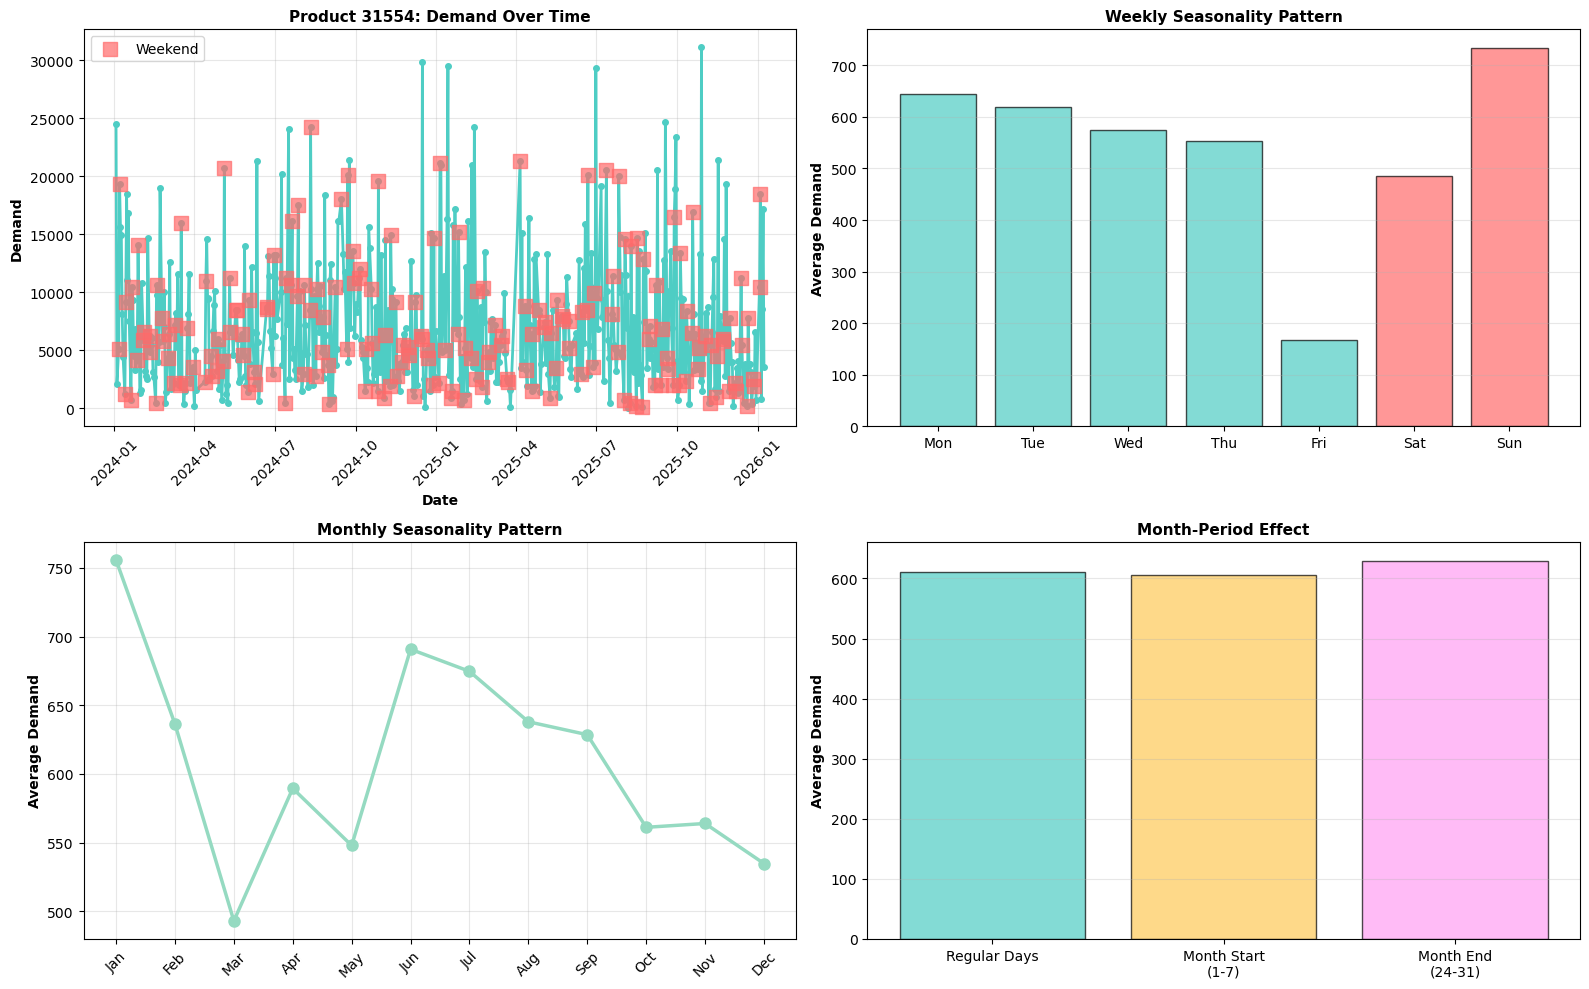


🔍 SEASONALITY INSIGHTS:
   Highest demand day: Sun (733.0 avg)
   Lowest demand day: Fri (167.8 avg)
   Weekend vs Weekday: 640.2 vs 602.1


In [11]:
# 📊 VISUALIZE: Temporal Patterns (Seasonality)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Sample one product for detailed view
sample_product = df_with_features['id_produit'].value_counts().index[0]
df_sample = df_with_features[df_with_features['id_produit'] == sample_product].sort_values('date')

# 1. Demand over time with weekend highlighting
axes[0, 0].plot(df_sample['date'], df_sample['quantite_demande'], linewidth=2, color='#4ECDC4', marker='o', markersize=4)
# Highlight weekends
weekend_mask = df_sample['is_weekend'] == 1
if weekend_mask.sum() > 0:
    axes[0, 0].scatter(df_sample[weekend_mask]['date'], df_sample[weekend_mask]['quantite_demande'], 
                       color='#FF6B6B', s=100, marker='s', label='Weekend', zorder=5, alpha=0.7)
axes[0, 0].set_xlabel('Date', fontsize=10, fontweight='bold')
axes[0, 0].set_ylabel('Demand', fontsize=10, fontweight='bold')
axes[0, 0].set_title(f'Product {sample_product}: Demand Over Time', fontsize=11, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Demand by day of week (all products)
weekly_pattern = df_with_features.groupby('day_of_week')['quantite_demande'].mean().sort_index()
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
colors = ['#4ECDC4' if i < 5 else '#FF6B6B' for i in range(7)]
axes[0, 1].bar(range(7), weekly_pattern.values, color=colors, alpha=0.7, edgecolor='black')
axes[0, 1].set_xticks(range(7))
axes[0, 1].set_xticklabels(day_names)
axes[0, 1].set_ylabel('Average Demand', fontsize=10, fontweight='bold')
axes[0, 1].set_title('Weekly Seasonality Pattern', fontsize=11, fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Demand by month (all products)
monthly_pattern = df_with_features.groupby('month')['quantite_demande'].mean().sort_index()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
axes[1, 0].plot(monthly_pattern.index, monthly_pattern.values, marker='o', linewidth=2.5, markersize=8, color='#95DAC1')
axes[1, 0].set_xticks(monthly_pattern.index)
axes[1, 0].set_xticklabels([month_names[i-1] for i in monthly_pattern.index], rotation=45)
axes[1, 0].set_ylabel('Average Demand', fontsize=10, fontweight='bold')
axes[1, 0].set_title('Monthly Seasonality Pattern', fontsize=11, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# 4. Month start/end effect
labels = ['Regular Days', 'Month Start\n(1-7)', 'Month End\n(24-31)']
values = [
    df_with_features[(df_with_features['is_month_start'] == 0) & (df_with_features['is_month_end'] == 0)]['quantite_demande'].mean(),
    df_with_features[df_with_features['is_month_start'] == 1]['quantite_demande'].mean(),
    df_with_features[df_with_features['is_month_end'] == 1]['quantite_demande'].mean()
]
colors_bar = ['#4ECDC4', '#FECA57', '#FF9FF3']
axes[1, 1].bar(range(3), values, color=colors_bar, alpha=0.7, edgecolor='black')
axes[1, 1].set_xticks(range(3))
axes[1, 1].set_xticklabels(labels)
axes[1, 1].set_ylabel('Average Demand', fontsize=10, fontweight='bold')
axes[1, 1].set_title('Month-Period Effect', fontsize=11, fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n🔍 SEASONALITY INSIGHTS:")
print(f"   Highest demand day: {day_names[weekly_pattern.argmax()]} ({weekly_pattern.max():.1f} avg)")
print(f"   Lowest demand day: {day_names[weekly_pattern.argmin()]} ({weekly_pattern.min():.1f} avg)")
print(f"   Weekend vs Weekday: {df_with_features[df_with_features['is_weekend']==1]['quantite_demande'].mean():.1f} vs {df_with_features[df_with_features['is_weekend']==0]['quantite_demande'].mean():.1f}")

## 🛠️ STEP 3: LAGGED & ROLLING FEATURES

Tomorrow's demand is often related to what happened yesterday or last week. We create rolling averages to capture trends.

In [12]:
def create_features(df):
    df = df.sort_values(['id_produit', 'date']).copy()
    
    # Lags
    for lag in [1, 7, 30]:
        df[f'lag_{lag}d'] = df.groupby('id_produit')['quantite_demande'].shift(lag)
    
    # Rolling means
    for window in [7, 30]:
        df[f'rolling_mean_{window}d'] = df.groupby('id_produit')['quantite_demande'].transform(
            lambda x: x.rolling(window=window, min_periods=1).mean()
        )
        
    return df.fillna(0)

df_final = create_features(df_with_features)
print("Lagged and rolling features created.")
df_final.head()

Lagged and rolling features created.


,id_produit,date,categorie,colisage fardeau,colisage palette,volume pcs (m3),Is_Gerbable,quantite_demande,year,month,...,day_of_week,week_of_year,is_weekend,is_month_start,is_month_end,lag_1d,lag_7d,lag_30d,rolling_mean_7d,rolling_mean_30d
0,31334,2024-01-07,MOULURE,32,1600,0.0002,True,544,2024,1,...,6,1,1,1,0,0.0,0.0,0.0,544.000000,544.000000
1,31334,2024-01-09,MOULURE,32,1600,0.0002,True,64,2024,1,...,1,2,0,0,0,544.0,0.0,0.0,304.000000,304.000000
2,31334,2024-01-10,MOULURE,32,1600,0.0002,True,32,2024,1,...,2,2,0,0,0,64.0,0.0,0.0,213.333333,213.333333
3,31334,2024-01-11,MOULURE,32,1600,0.0002,True,64,2024,1,...,3,2,0,0,0,32.0,0.0,0.0,176.000000,176.000000
4,31334,2024-01-15,MOULURE,32,1600,0.0002,True,192,2024,1,...,0,3,0,0,0,64.0,0.0,0.0,179.200000,179.200000


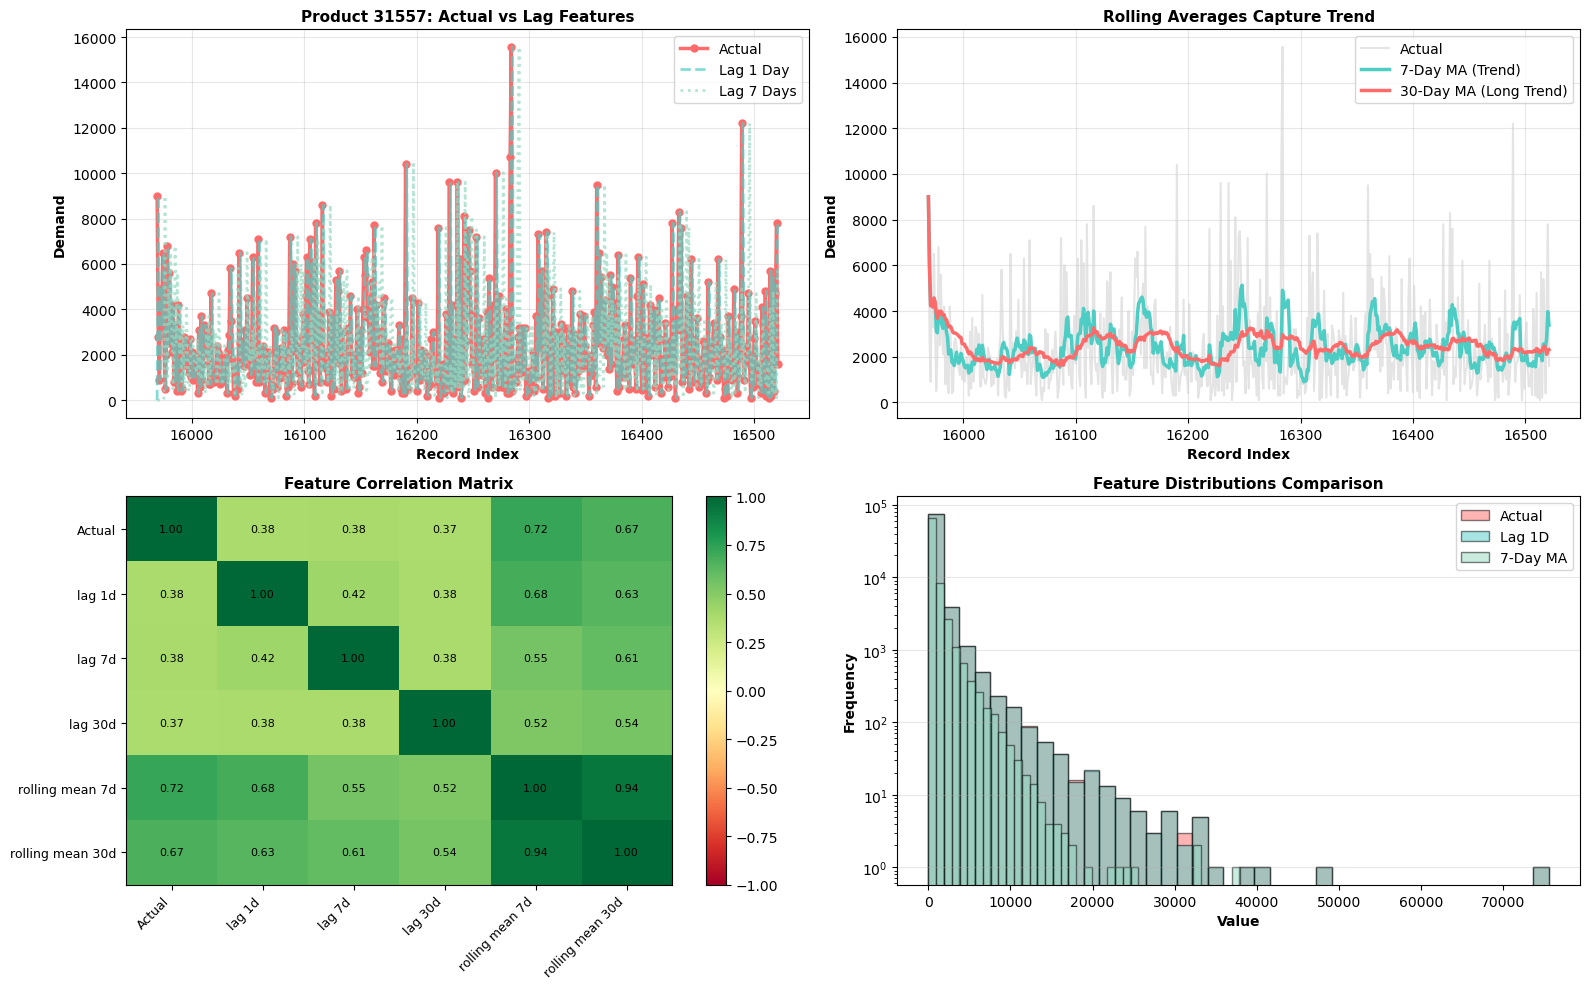


🔍 LAG & TREND INSIGHTS:
   Correlation actual vs lag_1d: 0.382
   Correlation actual vs lag_7d: 0.384
   Correlation actual vs 7-day MA: 0.722

   💡 High correlation means past values predict future well!


In [13]:
# 📊 VISUALIZE: Lagged Features & Trend Capture
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Get sample product with complete data
sample_product = df_final['id_produit'].value_counts().nlargest(10).index[5]
df_sample = df_final[df_final['id_produit'] == sample_product].sort_values('date').copy()

# 1. Actual vs Lag Features
axes[0, 0].plot(df_sample.index, df_sample['quantite_demande'], label='Actual', linewidth=2.5, color='#FF6B6B', marker='o', markersize=5)
axes[0, 0].plot(df_sample.index, df_sample['lag_1d'], label='Lag 1 Day', linewidth=2, color='#4ECDC4', linestyle='--', alpha=0.7)
axes[0, 0].plot(df_sample.index, df_sample['lag_7d'], label='Lag 7 Days', linewidth=2, color='#95DAC1', linestyle=':', alpha=0.7)
axes[0, 0].set_xlabel('Record Index', fontsize=10, fontweight='bold')
axes[0, 0].set_ylabel('Demand', fontsize=10, fontweight='bold')
axes[0, 0].set_title(f'Product {sample_product}: Actual vs Lag Features', fontsize=11, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 2. Rolling Mean - Trend Indicator
axes[0, 1].plot(df_sample.index, df_sample['quantite_demande'], label='Actual', linewidth=1.5, color='lightgray', alpha=0.6)
axes[0, 1].plot(df_sample.index, df_sample['rolling_mean_7d'], label='7-Day MA (Trend)', linewidth=2.5, color='#4ECDC4')
axes[0, 1].plot(df_sample.index, df_sample['rolling_mean_30d'], label='30-Day MA (Long Trend)', linewidth=2.5, color='#FF6B6B')
axes[0, 1].set_xlabel('Record Index', fontsize=10, fontweight='bold')
axes[0, 1].set_ylabel('Demand', fontsize=10, fontweight='bold')
axes[0, 1].set_title('Rolling Averages Capture Trend', fontsize=11, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# 3. Correlation heatmap between features
feature_cols = ['quantite_demande', 'lag_1d', 'lag_7d', 'lag_30d', 'rolling_mean_7d', 'rolling_mean_30d']
corr_matrix = df_final[feature_cols].corr()
im = axes[1, 0].imshow(corr_matrix, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
axes[1, 0].set_xticks(range(len(feature_cols)))
axes[1, 0].set_yticks(range(len(feature_cols)))
axes[1, 0].set_xticklabels([col.replace('quantite_demande', 'Actual').replace('_', ' ') for col in feature_cols], rotation=45, ha='right', fontsize=9)
axes[1, 0].set_yticklabels([col.replace('quantite_demande', 'Actual').replace('_', ' ') for col in feature_cols], fontsize=9)
axes[1, 0].set_title('Feature Correlation Matrix', fontsize=11, fontweight='bold')

# Add correlation values
for i in range(len(feature_cols)):
    for j in range(len(feature_cols)):
        text = axes[1, 0].text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                               ha="center", va="center", color="black", fontsize=8)

fig.colorbar(im, ax=axes[1, 0])

# 4. Distribution of features
axes[1, 1].hist(df_final['quantite_demande'], bins=40, alpha=0.5, label='Actual', color='#FF6B6B', edgecolor='black')
axes[1, 1].hist(df_final['lag_1d'], bins=40, alpha=0.5, label='Lag 1D', color='#4ECDC4', edgecolor='black')
axes[1, 1].hist(df_final['rolling_mean_7d'], bins=40, alpha=0.5, label='7-Day MA', color='#95DAC1', edgecolor='black')
axes[1, 1].set_xlabel('Value', fontsize=10, fontweight='bold')
axes[1, 1].set_ylabel('Frequency', fontsize=10, fontweight='bold')
axes[1, 1].set_title('Feature Distributions Comparison', fontsize=11, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)
axes[1, 1].set_yscale('log')

plt.tight_layout()
plt.show()

print("\n🔍 LAG & TREND INSIGHTS:")
print(f"   Correlation actual vs lag_1d: {df_final['quantite_demande'].corr(df_final['lag_1d']):.3f}")
print(f"   Correlation actual vs lag_7d: {df_final['quantite_demande'].corr(df_final['lag_7d']):.3f}")
print(f"   Correlation actual vs 7-day MA: {df_final['quantite_demande'].corr(df_final['rolling_mean_7d']):.3f}")
print(f"\n   💡 High correlation means past values predict future well!")

## 🛠️ STEP 4: PRODUCT SEGMENTATION

Not all products behave the same. Some are ordered every day in large quantities, while others are rare. We segment them to apply the best model for each.

In [14]:
def segment_products(df):
    # Calculate stats per product
    stats = df.groupby('id_produit').agg({
        'quantite_demande': ['count', 'mean', 'std'],
        'date': lambda x: (x.max() - x.min()).days
    }).reset_index()
    
    stats.columns = ['id_produit', 'order_days', 'avg_qty', 'std_qty', 'days_span']
    stats['frequency'] = stats['order_days'] / (stats['days_span'] + 1)
    
    def classify(row):
        if row['frequency'] > 0.8 and row['avg_qty'] > 500: return 'A_HIGH_FREQ_VOL'
        if row['frequency'] > 0.5: return 'B_MEDIUM_FREQ'
        return 'C_LOW_FREQ'
    
    stats['segment'] = stats.apply(classify, axis=1)
    return stats

product_segments = segment_products(df_final)
df_final = df_final.merge(product_segments[['id_produit', 'segment']], on='id_produit')
print("Product segmentation complete.")
print(df_final['segment'].value_counts())

Product segmentation complete.
segment
C_LOW_FREQ         46915
B_MEDIUM_FREQ      33702
A_HIGH_FREQ_VOL       34
Name: count, dtype: int64


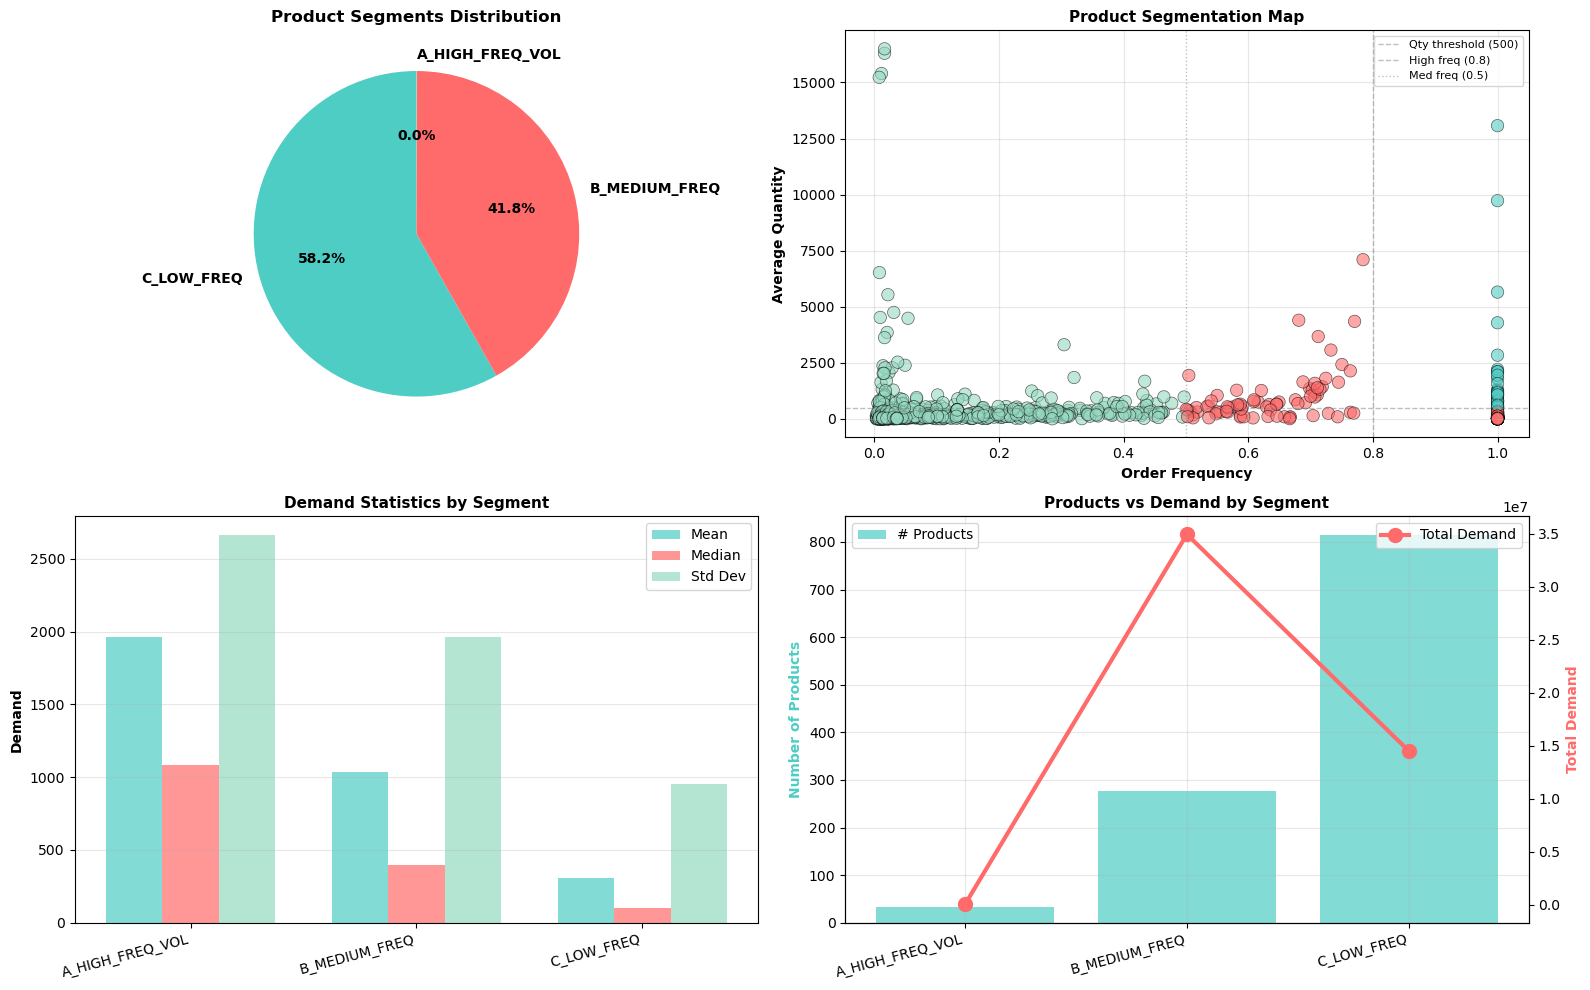


🔍 SEGMENTATION INSIGHTS:

   C_LOW_FREQ:
      Products: 814
      Avg demand: 309.52
      Total demand: 14,521,186
      Volatility (std): 955.18

   B_MEDIUM_FREQ:
      Products: 276
      Avg demand: 1036.83
      Total demand: 34,943,125
      Volatility (std): 1964.44

   A_HIGH_FREQ_VOL:
      Products: 34
      Avg demand: 1965.79
      Total demand: 66,837
      Volatility (std): 2661.65


In [15]:
# 📊 VISUALIZE: Product Segmentation
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Segment distribution
segment_counts = df_final['segment'].value_counts()
colors_seg = ['#4ECDC4', '#FF6B6B', '#95DAC1']
axes[0, 0].pie(segment_counts.values, labels=segment_counts.index, autopct='%1.1f%%',
               colors=colors_seg, startangle=90, textprops={'fontsize': 10, 'fontweight': 'bold'})
axes[0, 0].set_title('Product Segments Distribution', fontsize=12, fontweight='bold')

# 2. Frequency vs Average Quantity Scatter
axes[0, 1].scatter(product_segments['frequency'], product_segments['avg_qty'], 
                   c=[colors_seg[0] if seg == 'A_HIGH_FREQ_VOL' else colors_seg[1] if seg == 'B_MEDIUM_FREQ' else colors_seg[2] 
                     for seg in product_segments['segment']], 
                   alpha=0.6, s=80, edgecolors='black', linewidth=0.5)

# Add segment boundary lines
axes[0, 1].axhline(y=500, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Qty threshold (500)')
axes[0, 1].axvline(x=0.8, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='High freq (0.8)')
axes[0, 1].axvline(x=0.5, color='gray', linestyle=':', linewidth=1, alpha=0.5, label='Med freq (0.5)')
axes[0, 1].set_xlabel('Order Frequency', fontsize=10, fontweight='bold')
axes[0, 1].set_ylabel('Average Quantity', fontsize=10, fontweight='bold')
axes[0, 1].set_title('Product Segmentation Map', fontsize=11, fontweight='bold')
axes[0, 1].legend(fontsize=8)
axes[0, 1].grid(alpha=0.3)

# 3. Demand characteristics by segment
segment_demand = df_final.groupby('segment').agg({
    'quantite_demande': ['mean', 'median', 'std']
}).reset_index()
segment_demand.columns = ['segment', 'mean', 'median', 'std']

x = np.arange(len(segment_demand))
width = 0.25
axes[1, 0].bar(x - width, segment_demand['mean'], width, label='Mean', color='#4ECDC4', alpha=0.7)
axes[1, 0].bar(x, segment_demand['median'], width, label='Median', color='#FF6B6B', alpha=0.7)
axes[1, 0].bar(x + width, segment_demand['std'], width, label='Std Dev', color='#95DAC1', alpha=0.7)
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(segment_demand['segment'], rotation=15, ha='right')
axes[1, 0].set_ylabel('Demand', fontsize=10, fontweight='bold')
axes[1, 0].set_title('Demand Statistics by Segment', fontsize=11, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. Number of products and total demand by segment
segment_stats = df_final.groupby('segment').agg({
    'id_produit': 'nunique',
    'quantite_demande': 'sum'
}).reset_index()
segment_stats.columns = ['segment', 'num_products', 'total_demand']

ax1 = axes[1, 1]
ax2 = ax1.twinx()

bars1 = ax1.bar(range(len(segment_stats)), segment_stats['num_products'], alpha=0.7, color='#4ECDC4', label='# Products')
ax2.plot(range(len(segment_stats)), segment_stats['total_demand'], marker='o', markersize=10, 
         linewidth=3, color='#FF6B6B', label='Total Demand')

ax1.set_xticks(range(len(segment_stats)))
ax1.set_xticklabels(segment_stats['segment'], rotation=15, ha='right')
ax1.set_ylabel('Number of Products', fontsize=10, fontweight='bold', color='#4ECDC4')
ax2.set_ylabel('Total Demand', fontsize=10, fontweight='bold', color='#FF6B6B')
ax1.set_title('Products vs Demand by Segment', fontsize=11, fontweight='bold')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
ax1.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n🔍 SEGMENTATION INSIGHTS:")
for seg in segment_counts.index:
    seg_data = df_final[df_final['segment'] == seg]
    print(f"\n   {seg}:")
    print(f"      Products: {seg_data['id_produit'].nunique()}")
    print(f"      Avg demand: {seg_data['quantite_demande'].mean():.2f}")
    print(f"      Total demand: {seg_data['quantite_demande'].sum():,.0f}")
    print(f"      Volatility (std): {seg_data['quantite_demande'].std():.2f}")

## 🛠️ STEP 5: FORECASTING MODELS

We define our models, ranging from simple averages to Machine Learning.

In [16]:
from sklearn.ensemble import RandomForestRegressor

def get_naive_forecast(history, window=7):
    return history.tail(window).mean()

def train_rf_model(train_df, features):
    model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
    model.fit(train_df[features], train_df['quantite_demande'])
    return model

print("Model functions defined.")

Model functions defined.


## 🛠️ STEP 6: ORCHESTRATION - GENERATING THE ORDER

We combine the models to generate the final **Preparation Order** for a target date.

In [17]:
def generate_order(df, target_date):
    # Sample logic for a single product to demonstrate
    # In production, this would loop through segments and use mapped models
    history = df[df['date'] < target_date]
    
    # Naive example
    forecast = history.groupby('id_produit')['quantite_demande'].mean().reset_index()
    forecast.columns = ['id_produit', 'forecasted_quantity']
    
    return forecast

target_date = df['date'].max()
prep_order = generate_order(df_final, target_date)
print(f"Generated Preparation Order for {target_date.date()} with {len(prep_order)} items.")

Generated Preparation Order for 2026-01-08 with 1124 items.


## 📊 STEP 7: EVALUATION & VALIDATION

Finally, we evaluate our forecast against actual demand to measure accuracy (MAPE, Bias, Service Level).

In [18]:
from sklearn.metrics import mean_absolute_error

def evaluate(actual, forecast):
    mae = mean_absolute_error(actual, forecast)
    print(f"MAE: {mae:.2f} units")
    return mae

print("Evaluation logic ready.")

Evaluation logic ready.
